# GTSRB Traffic Sign Recognition with Data Augmentation

In [2]:
import torch
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import time
import os

import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "util"))
import vcpi_util

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

BASE_PATH     = '..'                           
PATH_TRAIN    = f'{BASE_PATH}/images/train_images'
PATH_TEST     = f'{BASE_PATH}/images/test_images'
PATH_MODELS   = f'{BASE_PATH}/models'

BATCH_SIZE = 32
EPOCHS     = 50
RUNS       = 5   # professor disse mínimo 5 runs, fazer média
NUM_CLASSES = 43  # pastas 00000 a 00042
IMG_SIZE    = 32  # GTSRB usa 32x32

cuda:0


## Auxiliar Functions

In [4]:
class EarlyStopping:
    def __init__(self, patience=9, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.min_val_loss = float('inf')

    def __call__(self, val_loss):
        if val_loss + self.min_delta < self.min_val_loss:
            self.min_val_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter > self.patience:
                return True
        return False


def train(model, train_loader, val_loader, epochs, loss_fn, optimizer,
          scheduler, early_stopper, save_path):
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = np.inf

    for epoch in range(epochs):
        model.train()
        running_loss, correct = 0.0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            loss = loss_fn(outputs, targets)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (predicted == targets).sum()

        model.eval()
        val_loss, v_correct = 0.0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_loss += loss_fn(outputs, targets).item() * targets.size(0)
                v_correct += (preds == targets).sum()

        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        if old_lr != new_lr:
            print(f'  LR: {old_lr} → {new_lr}')

        epoch_loss = running_loss / len(train_loader.dataset)
        acc        = 100 * correct / len(train_loader.dataset)
        v_acc      = 100 * v_correct / len(val_loader.dataset)
        val_loss  /= len(val_loader.dataset)

        history['loss'].append(epoch_loss)
        history['accuracy'].append(acc.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(v_acc.cpu().numpy())

        print(f'Epoch {epoch:03d} | Loss: {epoch_loss:.4f} | Acc: {acc:.2f}% '
              f'| Val Loss: {val_loss:.4f} | Val Acc: {v_acc:.2f}%')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'scheduler': scheduler.state_dict()}, save_path)

        if early_stopper(val_loss):
            print('Early stopping!')
            break

    print('Treino concluído.\n')
    return history


def evaluate(model, data_loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for images, targets in data_loader:
            outputs = model(images.to(device))
            _, preds = torch.max(outputs, 1)
            correct += (preds.cpu() == targets).sum()
    return (correct / len(data_loader.dataset)).item()


def run_experiment(name, transform_train, transform_test, n_runs=RUNS):
    print(f'\n{"="*60}')
    print(f'EXPERIÊNCIA: {name}')
    print(f'{"="*60}')

    # Divisão treino/validação (80/20) a partir do train_images
    full_train = torchvision.datasets.ImageFolder(
        root=PATH_TRAIN, transform=transform_train)
    
    val_size   = int(0.2 * len(full_train))
    train_size = len(full_train) - val_size
    train_set, val_set = torch.utils.data.random_split(
        full_train, [train_size, val_size],
        generator=torch.Generator().manual_seed(42))

    val_set.dataset.transform = transform_base

    test_set = torchvision.datasets.ImageFolder(
        root=PATH_TEST, transform=transform_test)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = torch.utils.data.DataLoader(
        val_set,   batch_size=BATCH_SIZE)
    test_loader  = torch.utils.data.DataLoader(
        test_set,  batch_size=BATCH_SIZE)

    results = []
    for i in range(n_runs):
        print(f'\n--- Run {i+1}/{n_runs} ---')
        model = Conv_II(NUM_CLASSES).to(device)
        loss_fn    = torch.nn.CrossEntropyLoss()
        optimizer  = torch.optim.Adam(model.parameters())
        scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                         optimizer, mode='min', factor=0.1, patience=3)
        early_stop = EarlyStopping(patience=9)
        save_path  = f'{PATH_MODELS}/{name}_run{i}.pt'

        history = train(model, train_loader, val_loader, EPOCHS,
                        loss_fn, optimizer, scheduler, early_stop, save_path)

        # Recarregar melhor checkpoint
        checkpoint = torch.load(save_path)
        model.load_state_dict(checkpoint['model'])
        acc = evaluate(model, test_loader)
        print(f'Test Accuracy (run {i}): {acc*100:.2f}%')
        results.append(acc)

    mean_acc = np.mean(results)
    std_acc  = np.std(results)
    print(f'\n→ {name}: média = {mean_acc*100:.2f}% | std = {std_acc*100:.2f}%')
    return results, mean_acc, std_acc


## Dataset Analysis

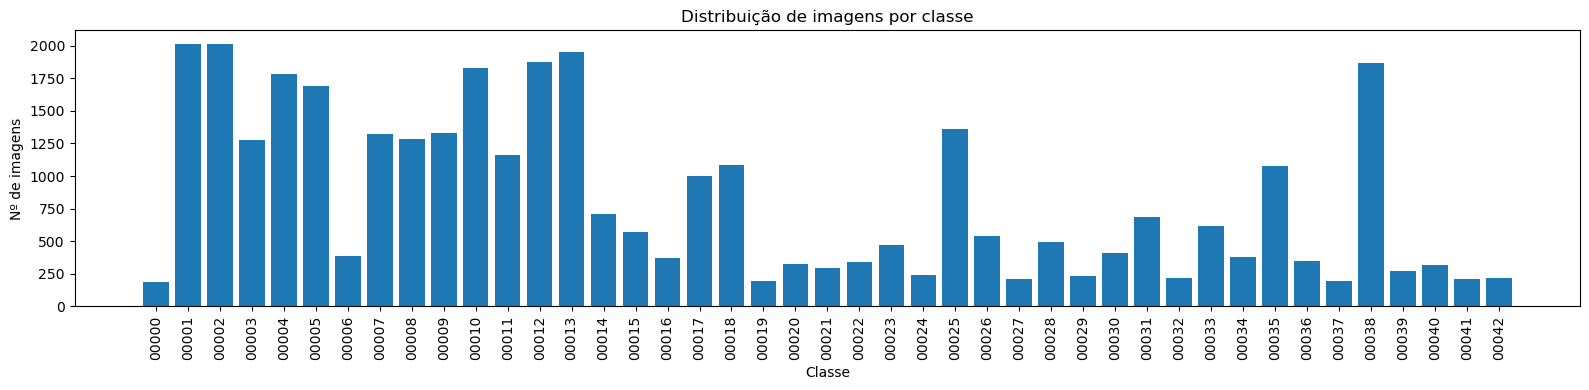

Classe com mais imagens:  00002 (2016 imgs)
Classe com menos imagens: 00000 (188 imgs)


In [5]:
from collections import Counter
import pathlib

class_counts = Counter()
for cls in sorted(os.listdir(PATH_TRAIN)):
    cls_path = os.path.join(PATH_TRAIN, cls)
    if os.path.isdir(cls_path):
        class_counts[cls] = len(list(pathlib.Path(cls_path).glob('*.ppm')))

plt.figure(figsize=(16,4))
plt.bar(class_counts.keys(), class_counts.values())
plt.title('Distribuição de imagens por classe')
plt.xlabel('Classe')
plt.ylabel('Nº de imagens')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(f"Classe com mais imagens:  {max(class_counts, key=class_counts.get)} ({max(class_counts.values())} imgs)")
print(f"Classe com menos imagens: {min(class_counts, key=class_counts.get)} ({min(class_counts.values())} imgs)")

In [6]:
transform_base = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

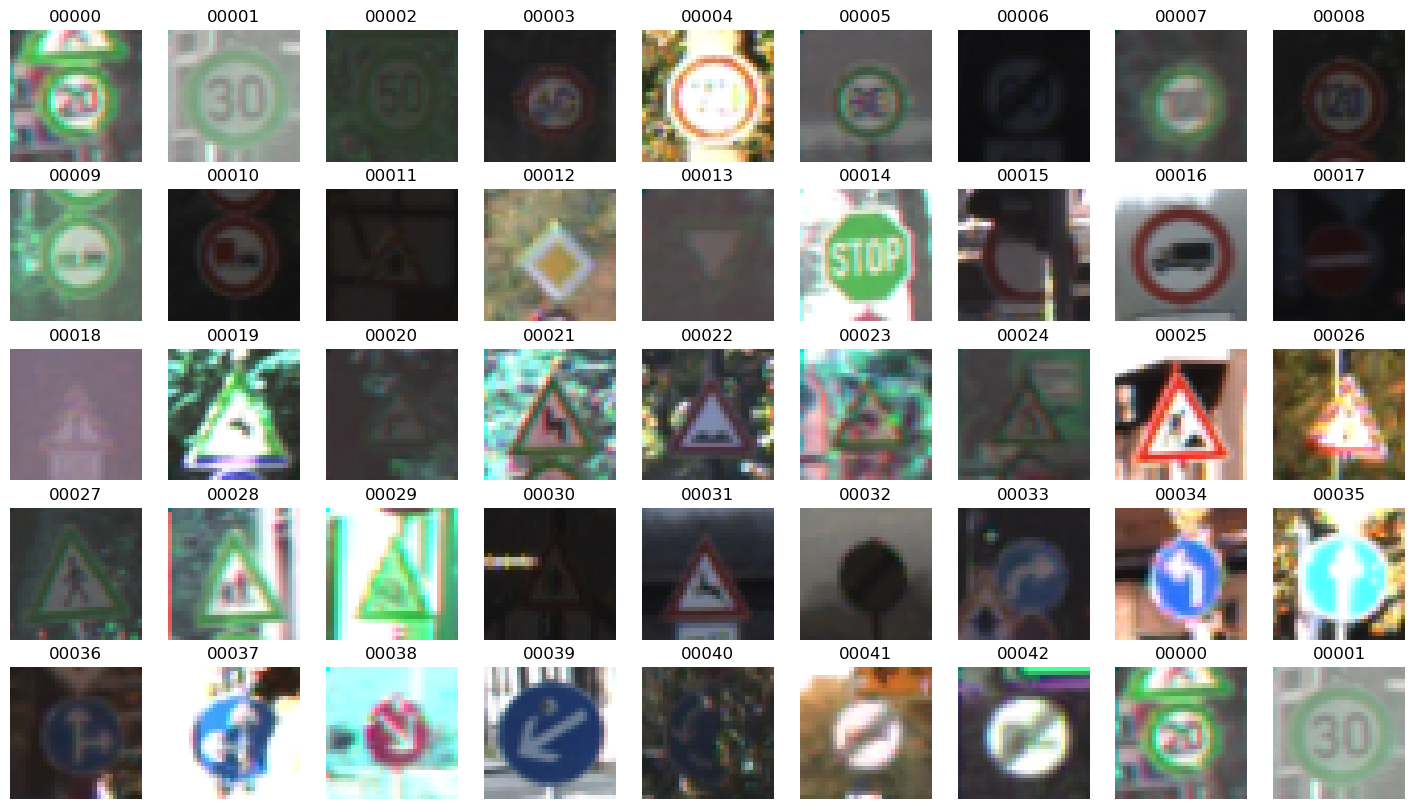

<Figure size 640x480 with 0 Axes>

In [7]:
train_set_visualization = torchvision.datasets.ImageFolder(
        root=PATH_TRAIN, transform=transform_base)

train_loader_visualization = torch.utils.data.DataLoader(
        train_set_visualization, batch_size=BATCH_SIZE, shuffle=True)

#images, targets = next(iter(train_loader_visualization))
#print("Batch shape: ", images.shape)

#print(targets)

class_to_idx = {}
for idx, (_, label) in enumerate(train_set_visualization.samples):
    if label not in class_to_idx:
        class_to_idx[label] = idx
    if len(class_to_idx) == NUM_CLASSES:
        break

indices = [class_to_idx[c] for c in sorted(class_to_idx)]
images  = torch.stack([train_set_visualization[i][0] for i in indices])
targets = torch.tensor(sorted(class_to_idx.keys()))
rows, cols = 5, 9
n = rows * cols

images_padded  = torch.cat([images,  images[:n - len(images)]])
targets_padded = torch.cat([targets, targets[:n - len(targets)]])

vcpi_util.show_images(rows, cols, images_padded, targets_padded,
                      train_set_visualization.classes)

## Model

In [8]:
class Conv_II(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1   = torch.nn.Conv2d(3, 16, 3)
        self.bn1     = torch.nn.BatchNorm2d(16)
        self.relu1   = torch.nn.ReLU()
        self.conv2   = torch.nn.Conv2d(16, 32, 3)
        self.bn2     = torch.nn.BatchNorm2d(32)
        self.relu2   = torch.nn.ReLU()
        self.maxpool1 = torch.nn.MaxPool2d(2)
        self.conv3   = torch.nn.Conv2d(32, 48, 3)
        self.bn3     = torch.nn.BatchNorm2d(48)
        self.relu3   = torch.nn.ReLU()
        self.conv4   = torch.nn.Conv2d(48, 48, 3)
        self.bn4     = torch.nn.BatchNorm2d(48)
        self.relu4   = torch.nn.ReLU()
        self.maxpool2 = torch.nn.MaxPool2d(2)
        self.dropout = torch.nn.Dropout(p=0.5)
        self.fc1     = torch.nn.Linear(48, num_classes)

    def forward(self, x):
        x = self.relu1(self.bn1(self.conv1(x)))
        x = self.relu2(self.bn2(self.conv2(x)))
        x = self.maxpool1(x)
        x = self.relu3(self.bn3(self.conv3(x)))
        x = self.relu4(self.bn4(self.conv4(x)))
        x = self.maxpool2(x)
        x = torch.mean(x, dim=[2, 3])  
        x = self.dropout(x)
        x = self.fc1(x)
        return x

## Experience 0 - Baseline

In [8]:
results_base, mean_base, std_base = run_experiment(
    name='baseline',
    transform_train=transform_base,
    transform_test=transform_base
)


EXPERIÊNCIA: baseline

--- Run 1/5 ---
Epoch 000 | Loss: 2.5921 | Acc: 27.99% | Val Loss: 1.7545 | Val Acc: 46.99%
Epoch 001 | Loss: 1.5941 | Acc: 52.04% | Val Loss: 0.9970 | Val Acc: 71.96%
Epoch 002 | Loss: 1.0572 | Acc: 68.66% | Val Loss: 0.5556 | Val Acc: 84.24%
Epoch 003 | Loss: 0.7298 | Acc: 78.42% | Val Loss: 0.3915 | Val Acc: 89.55%
Epoch 004 | Loss: 0.5250 | Acc: 84.82% | Val Loss: 0.1966 | Val Acc: 97.07%
Epoch 005 | Loss: 0.4129 | Acc: 88.26% | Val Loss: 0.1824 | Val Acc: 97.47%
Epoch 006 | Loss: 0.3264 | Acc: 90.71% | Val Loss: 0.1053 | Val Acc: 98.32%
Epoch 007 | Loss: 0.2733 | Acc: 92.35% | Val Loss: 0.0987 | Val Acc: 98.22%
Epoch 008 | Loss: 0.2384 | Acc: 93.30% | Val Loss: 0.0995 | Val Acc: 98.88%
Epoch 009 | Loss: 0.2079 | Acc: 94.15% | Val Loss: 0.0528 | Val Acc: 99.01%
Epoch 010 | Loss: 0.1868 | Acc: 94.71% | Val Loss: 0.0410 | Val Acc: 99.45%
Epoch 011 | Loss: 0.1611 | Acc: 95.39% | Val Loss: 0.0494 | Val Acc: 99.12%
Epoch 012 | Loss: 0.1587 | Acc: 95.32% | Val Los

C:\Users\Asus\AppData\Local\Temp\ipykernel_24648\790700772.py:134: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path)


Test Accuracy (run 0): 97.36%

--- Run 2/5 ---
Epoch 000 | Loss: 2.4841 | Acc: 31.33% | Val Loss: 1.8919 | Val Acc: 42.58%
Epoch 001 | Loss: 1.5536 | Acc: 53.60% | Val Loss: 1.0735 | Val Acc: 67.52%
Epoch 002 | Loss: 1.0579 | Acc: 68.64% | Val Loss: 0.5838 | Val Acc: 86.32%
Epoch 003 | Loss: 0.7440 | Acc: 78.12% | Val Loss: 0.3653 | Val Acc: 90.75%
Epoch 004 | Loss: 0.5499 | Acc: 84.01% | Val Loss: 0.2385 | Val Acc: 96.15%
Epoch 005 | Loss: 0.4214 | Acc: 87.96% | Val Loss: 0.1634 | Val Acc: 96.28%
Epoch 006 | Loss: 0.3411 | Acc: 90.25% | Val Loss: 0.1251 | Val Acc: 97.51%
Epoch 007 | Loss: 0.2967 | Acc: 91.55% | Val Loss: 0.1285 | Val Acc: 98.16%
Epoch 008 | Loss: 0.2514 | Acc: 92.85% | Val Loss: 0.0653 | Val Acc: 98.94%
Epoch 009 | Loss: 0.2198 | Acc: 93.75% | Val Loss: 0.0631 | Val Acc: 98.83%
Epoch 010 | Loss: 0.2012 | Acc: 94.20% | Val Loss: 0.0446 | Val Acc: 99.18%
Epoch 011 | Loss: 0.1816 | Acc: 94.97% | Val Loss: 0.0366 | Val Acc: 99.38%
Epoch 012 | Loss: 0.1582 | Acc: 95.31% | 

## Experience 1 - Augmentation Geométrica

In [9]:
transform_geo = v2.Compose([
    v2.RandomRotation(15, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

results_geo, mean_geo, std_geo = run_experiment(
    name='aug_geometrica',
    transform_train=transform_geo,
    transform_test=transform_base
)


EXPERIÊNCIA: aug_geometrica

--- Run 1/5 ---
Epoch 000 | Loss: 2.5198 | Acc: 29.88% | Val Loss: 1.6749 | Val Acc: 49.95%
Epoch 001 | Loss: 1.5795 | Acc: 52.03% | Val Loss: 1.0155 | Val Acc: 73.32%
Epoch 002 | Loss: 1.0902 | Acc: 67.38% | Val Loss: 0.6442 | Val Acc: 82.80%
Epoch 003 | Loss: 0.7745 | Acc: 77.16% | Val Loss: 0.3744 | Val Acc: 91.72%
Epoch 004 | Loss: 0.5681 | Acc: 83.57% | Val Loss: 0.2363 | Val Acc: 96.46%
Epoch 005 | Loss: 0.4405 | Acc: 87.41% | Val Loss: 0.2119 | Val Acc: 95.01%
Epoch 006 | Loss: 0.3549 | Acc: 89.91% | Val Loss: 0.1358 | Val Acc: 97.30%
Epoch 007 | Loss: 0.2862 | Acc: 91.86% | Val Loss: 0.1095 | Val Acc: 98.39%
Epoch 008 | Loss: 0.2470 | Acc: 93.00% | Val Loss: 0.0797 | Val Acc: 98.77%
Epoch 009 | Loss: 0.2226 | Acc: 93.56% | Val Loss: 0.0550 | Val Acc: 99.08%
Epoch 010 | Loss: 0.1899 | Acc: 94.53% | Val Loss: 0.0940 | Val Acc: 98.23%
Epoch 011 | Loss: 0.1721 | Acc: 95.12% | Val Loss: 0.0551 | Val Acc: 99.00%
Epoch 012 | Loss: 0.1614 | Acc: 95.38% | V

C:\Users\Asus\AppData\Local\Temp\ipykernel_24648\790700772.py:134: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path)


Test Accuracy (run 0): 97.45%

--- Run 2/5 ---
Epoch 000 | Loss: 2.5893 | Acc: 27.57% | Val Loss: 1.7096 | Val Acc: 48.97%
Epoch 001 | Loss: 1.6397 | Acc: 50.08% | Val Loss: 1.0561 | Val Acc: 72.44%
Epoch 002 | Loss: 1.1254 | Acc: 66.02% | Val Loss: 0.6135 | Val Acc: 84.68%
Epoch 003 | Loss: 0.7780 | Acc: 76.86% | Val Loss: 0.3922 | Val Acc: 94.19%
Epoch 004 | Loss: 0.5643 | Acc: 83.74% | Val Loss: 0.2054 | Val Acc: 97.06%
Epoch 005 | Loss: 0.4266 | Acc: 87.82% | Val Loss: 0.1448 | Val Acc: 98.02%
Epoch 006 | Loss: 0.3431 | Acc: 90.15% | Val Loss: 0.1141 | Val Acc: 98.43%
Epoch 007 | Loss: 0.2834 | Acc: 92.02% | Val Loss: 0.0863 | Val Acc: 98.85%
Epoch 008 | Loss: 0.2385 | Acc: 93.24% | Val Loss: 0.0649 | Val Acc: 98.74%
Epoch 009 | Loss: 0.2210 | Acc: 93.56% | Val Loss: 0.0546 | Val Acc: 99.08%
Epoch 010 | Loss: 0.1875 | Acc: 94.66% | Val Loss: 0.0435 | Val Acc: 99.28%
Epoch 011 | Loss: 0.1722 | Acc: 95.16% | Val Loss: 0.0632 | Val Acc: 98.61%
Epoch 012 | Loss: 0.1650 | Acc: 95.42% | 

## Experience 2 - Augmentation Geométrica 2

In [10]:
transform_geo2 = v2.Compose([
    v2.RandomPerspective(distortion_scale=0.2, p=0.6),
    v2.Resize((IMG_SIZE +8, IMG_SIZE +8)),
    v2.RandomCrop((IMG_SIZE, IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

results_geo2, mean_geo2, std_geo2 = run_experiment(
    name='aug_geometrica2',
    transform_train=transform_geo2,
    transform_test=transform_base
)


EXPERIÊNCIA: aug_geometrica2

--- Run 1/5 ---
Epoch 000 | Loss: 2.5473 | Acc: 29.25% | Val Loss: 1.6392 | Val Acc: 53.13%
Epoch 001 | Loss: 1.5734 | Acc: 52.24% | Val Loss: 0.9347 | Val Acc: 74.89%
Epoch 002 | Loss: 1.0578 | Acc: 68.20% | Val Loss: 0.6079 | Val Acc: 81.67%
Epoch 003 | Loss: 0.7376 | Acc: 77.87% | Val Loss: 0.3159 | Val Acc: 93.69%
Epoch 004 | Loss: 0.5477 | Acc: 84.19% | Val Loss: 0.1949 | Val Acc: 95.84%
Epoch 005 | Loss: 0.4212 | Acc: 88.02% | Val Loss: 0.1367 | Val Acc: 97.04%
Epoch 006 | Loss: 0.3310 | Acc: 90.81% | Val Loss: 0.1084 | Val Acc: 98.30%
Epoch 007 | Loss: 0.2810 | Acc: 92.13% | Val Loss: 0.0915 | Val Acc: 98.25%
Epoch 008 | Loss: 0.2351 | Acc: 93.47% | Val Loss: 0.0518 | Val Acc: 99.15%
Epoch 009 | Loss: 0.2054 | Acc: 94.26% | Val Loss: 0.0668 | Val Acc: 99.01%
Epoch 010 | Loss: 0.1792 | Acc: 95.13% | Val Loss: 0.0475 | Val Acc: 99.24%
Epoch 011 | Loss: 0.1625 | Acc: 95.43% | Val Loss: 0.0504 | Val Acc: 98.94%
Epoch 012 | Loss: 0.1472 | Acc: 95.87% | 

C:\Users\Asus\AppData\Local\Temp\ipykernel_24648\790700772.py:134: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path)


Test Accuracy (run 0): 97.57%

--- Run 2/5 ---
Epoch 000 | Loss: 2.4853 | Acc: 30.18% | Val Loss: 1.6051 | Val Acc: 52.85%
Epoch 001 | Loss: 1.4981 | Acc: 55.04% | Val Loss: 0.9394 | Val Acc: 75.40%
Epoch 002 | Loss: 0.9808 | Acc: 70.31% | Val Loss: 0.5140 | Val Acc: 87.83%
Epoch 003 | Loss: 0.6849 | Acc: 79.77% | Val Loss: 0.3199 | Val Acc: 94.54%
Epoch 004 | Loss: 0.4991 | Acc: 85.60% | Val Loss: 0.2039 | Val Acc: 97.23%
Epoch 005 | Loss: 0.3915 | Acc: 88.94% | Val Loss: 0.1619 | Val Acc: 97.57%
Epoch 006 | Loss: 0.3169 | Acc: 90.92% | Val Loss: 0.1099 | Val Acc: 98.27%
Epoch 007 | Loss: 0.2604 | Acc: 92.73% | Val Loss: 0.0629 | Val Acc: 98.92%
Epoch 008 | Loss: 0.2298 | Acc: 93.49% | Val Loss: 0.0663 | Val Acc: 98.88%
Epoch 009 | Loss: 0.2031 | Acc: 94.31% | Val Loss: 0.0540 | Val Acc: 98.90%
Epoch 010 | Loss: 0.1786 | Acc: 94.85% | Val Loss: 0.0535 | Val Acc: 98.98%
Epoch 011 | Loss: 0.1696 | Acc: 95.12% | Val Loss: 0.0393 | Val Acc: 99.28%
Epoch 012 | Loss: 0.1487 | Acc: 95.76% | 

## Experience 3 - Augmentation de Cor

In [11]:
transform_color = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

results_color, mean_color, std_color = run_experiment(
    name='aug_cor',
    transform_train=transform_color,
    transform_test=transform_base
)


EXPERIÊNCIA: aug_cor

--- Run 1/5 ---
Epoch 000 | Loss: 2.4817 | Acc: 30.46% | Val Loss: 1.6438 | Val Acc: 55.35%
Epoch 001 | Loss: 1.5101 | Acc: 55.20% | Val Loss: 1.0004 | Val Acc: 78.26%
Epoch 002 | Loss: 0.9911 | Acc: 70.85% | Val Loss: 0.4925 | Val Acc: 89.29%
Epoch 003 | Loss: 0.6903 | Acc: 79.67% | Val Loss: 0.3614 | Val Acc: 92.23%
Epoch 004 | Loss: 0.5195 | Acc: 85.29% | Val Loss: 0.2431 | Val Acc: 96.46%
Epoch 005 | Loss: 0.3917 | Acc: 88.86% | Val Loss: 0.1282 | Val Acc: 97.67%
Epoch 006 | Loss: 0.3220 | Acc: 91.08% | Val Loss: 0.1000 | Val Acc: 97.74%
Epoch 007 | Loss: 0.2678 | Acc: 92.50% | Val Loss: 0.0969 | Val Acc: 98.37%
Epoch 008 | Loss: 0.2332 | Acc: 93.33% | Val Loss: 0.0855 | Val Acc: 98.68%
Epoch 009 | Loss: 0.2041 | Acc: 94.24% | Val Loss: 0.0560 | Val Acc: 98.74%
Epoch 010 | Loss: 0.1807 | Acc: 94.92% | Val Loss: 0.0611 | Val Acc: 98.68%
Epoch 011 | Loss: 0.1606 | Acc: 95.52% | Val Loss: 0.0529 | Val Acc: 99.08%
Epoch 012 | Loss: 0.1523 | Acc: 95.48% | Val Loss

C:\Users\Asus\AppData\Local\Temp\ipykernel_24648\790700772.py:134: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path)


Test Accuracy (run 0): 97.43%

--- Run 2/5 ---
Epoch 000 | Loss: 2.5112 | Acc: 30.32% | Val Loss: 1.6417 | Val Acc: 54.35%
Epoch 001 | Loss: 1.5210 | Acc: 54.56% | Val Loss: 0.8970 | Val Acc: 74.44%
Epoch 002 | Loss: 0.9874 | Acc: 70.65% | Val Loss: 0.5100 | Val Acc: 87.78%
Epoch 003 | Loss: 0.6893 | Acc: 79.80% | Val Loss: 0.2742 | Val Acc: 93.49%
Epoch 004 | Loss: 0.4940 | Acc: 85.77% | Val Loss: 0.2178 | Val Acc: 96.19%
Epoch 005 | Loss: 0.3864 | Acc: 89.11% | Val Loss: 0.1253 | Val Acc: 98.15%
Epoch 006 | Loss: 0.3146 | Acc: 91.14% | Val Loss: 0.1113 | Val Acc: 98.27%
Epoch 007 | Loss: 0.2589 | Acc: 92.69% | Val Loss: 0.0673 | Val Acc: 98.87%
Epoch 008 | Loss: 0.2306 | Acc: 93.57% | Val Loss: 0.0646 | Val Acc: 98.81%
Epoch 009 | Loss: 0.2006 | Acc: 94.28% | Val Loss: 0.0591 | Val Acc: 98.91%
Epoch 010 | Loss: 0.1814 | Acc: 94.67% | Val Loss: 0.0542 | Val Acc: 99.05%
Epoch 011 | Loss: 0.1639 | Acc: 95.42% | Val Loss: 0.0500 | Val Acc: 99.19%
Epoch 012 | Loss: 0.1554 | Acc: 95.60% | 

## Experience 4 - Augmentation Combinada (geo + cor + erasing)

In [12]:
transform_combined = v2.Compose([
    v2.RandomRotation(15, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(p=0.3, scale=(0.02, 0.1), value='random')  # simula oclusão
])

results_comb, mean_comb, std_comb = run_experiment(
    name='aug_combinada',
    transform_train=transform_combined,
    transform_test=transform_base
)


EXPERIÊNCIA: aug_combinada

--- Run 1/5 ---
Epoch 000 | Loss: 2.5365 | Acc: 29.20% | Val Loss: 1.7220 | Val Acc: 52.24%
Epoch 001 | Loss: 1.5473 | Acc: 53.60% | Val Loss: 0.9090 | Val Acc: 77.14%
Epoch 002 | Loss: 1.0295 | Acc: 69.35% | Val Loss: 0.4894 | Val Acc: 88.95%
Epoch 003 | Loss: 0.7050 | Acc: 79.16% | Val Loss: 0.2906 | Val Acc: 94.60%
Epoch 004 | Loss: 0.5152 | Acc: 85.11% | Val Loss: 0.2180 | Val Acc: 96.73%
Epoch 005 | Loss: 0.3962 | Acc: 88.73% | Val Loss: 0.1769 | Val Acc: 97.76%
Epoch 006 | Loss: 0.3136 | Acc: 91.45% | Val Loss: 0.1188 | Val Acc: 98.42%
Epoch 007 | Loss: 0.2708 | Acc: 92.50% | Val Loss: 0.0796 | Val Acc: 99.14%
Epoch 008 | Loss: 0.2330 | Acc: 93.41% | Val Loss: 0.0792 | Val Acc: 98.76%
Epoch 009 | Loss: 0.2027 | Acc: 94.36% | Val Loss: 0.0572 | Val Acc: 99.11%
Epoch 010 | Loss: 0.1837 | Acc: 94.94% | Val Loss: 0.0442 | Val Acc: 99.08%
Epoch 011 | Loss: 0.1591 | Acc: 95.37% | Val Loss: 0.0377 | Val Acc: 99.39%
Epoch 012 | Loss: 0.1492 | Acc: 95.75% | Va

C:\Users\Asus\AppData\Local\Temp\ipykernel_24648\790700772.py:134: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path)


Test Accuracy (run 0): 97.77%

--- Run 2/5 ---
Epoch 000 | Loss: 2.5724 | Acc: 28.55% | Val Loss: 1.7001 | Val Acc: 52.54%
Epoch 001 | Loss: 1.6002 | Acc: 51.48% | Val Loss: 1.1171 | Val Acc: 66.40%
Epoch 002 | Loss: 1.0815 | Acc: 67.63% | Val Loss: 0.5867 | Val Acc: 83.31%
Epoch 003 | Loss: 0.7443 | Acc: 77.84% | Val Loss: 0.3260 | Val Acc: 93.80%
Epoch 004 | Loss: 0.5493 | Acc: 83.69% | Val Loss: 0.2187 | Val Acc: 96.24%
Epoch 005 | Loss: 0.4165 | Acc: 88.10% | Val Loss: 0.1682 | Val Acc: 96.51%
Epoch 006 | Loss: 0.3349 | Acc: 90.53% | Val Loss: 0.1151 | Val Acc: 98.30%
Epoch 007 | Loss: 0.2730 | Acc: 92.20% | Val Loss: 0.0944 | Val Acc: 98.49%
Epoch 008 | Loss: 0.2424 | Acc: 93.01% | Val Loss: 0.0840 | Val Acc: 98.60%
Epoch 009 | Loss: 0.2026 | Acc: 94.44% | Val Loss: 0.0617 | Val Acc: 99.12%
Epoch 010 | Loss: 0.1787 | Acc: 94.97% | Val Loss: 0.0455 | Val Acc: 99.18%
Epoch 011 | Loss: 0.1643 | Acc: 95.40% | Val Loss: 0.0617 | Val Acc: 98.46%
Epoch 012 | Loss: 0.1492 | Acc: 95.73% | 

## Experience 5 - Augmentation Combinada com Probabilidades Associadas

In [13]:
#transform_random = v2.Compose([
#    v2.RandomRotation(15, interpolation=v2.InterpolationMode.BILINEAR),
#    v2.Resize((IMG_SIZE, IMG_SIZE)),
#    v2.RandomApply([
#        v2.RandomPerspective(distortion_scale=0.2, p=1.0)
#    ], p=0.5)
#    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
#    v2.RandomApply([
#        v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
#    ], p=0.8)
#    v2.ToImage(),
#    v2.ToDtype(torch.float32, scale=True),
#    v2.RandomApply([
#        v2.RandomErasing(p=0.3, scale=(0.02, 0.1), value='random')  # simula oclusão
#    ], p=0.4)
#])

#results_random, mean_random, std_random = run_experiment(
#    name='aug_random',
#    transform_train=transform_random,
#    transform_test=transform_base
#)

## Experience 6 - Expansão Massiva do Dataset

In [8]:
transform_strong = v2.Compose([
    v2.RandomRotation(20, interpolation=v2.InterpolationMode.BILINEAR),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.3, hue=0.05),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomErasing(p=0.3, scale=(0.02, 0.1), value='random')
])

# Dataset expandido = original + versão augmentada
full_original  = torchvision.datasets.ImageFolder(root=PATH_TRAIN, transform=transform_base)
full_augmented = torchvision.datasets.ImageFolder(root=PATH_TRAIN, transform=transform_strong)
expanded_dataset = torch.utils.data.ConcatDataset([full_original, full_augmented])

train_size_exp = int(0.8 * len(expanded_dataset))
val_size_exp   = len(expanded_dataset) - train_size_exp
train_exp, val_exp = torch.utils.data.random_split(
    expanded_dataset, [train_size_exp, val_size_exp],
    generator=torch.Generator().manual_seed(42))

test_set = torchvision.datasets.ImageFolder(root=PATH_TEST, transform=transform_base)

train_loader_exp = torch.utils.data.DataLoader(train_exp, batch_size=BATCH_SIZE, shuffle=True)
val_loader_exp   = torch.utils.data.DataLoader(val_exp,   batch_size=BATCH_SIZE)
test_loader      = torch.utils.data.DataLoader(test_set,  batch_size=BATCH_SIZE)

results_exp = []
for i in range(RUNS):
    print(f'\n--- Expansão Massiva Run {i+1}/{RUNS} ---')
    model     = Conv_II(NUM_CLASSES).to(device)
    loss_fn   = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters())
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)
    early_stop = EarlyStopping(patience=9)
    save_path  = f'{PATH_MODELS}/aug_expansao_run{i}.pt'
    train(model, train_loader_exp, val_loader_exp, EPOCHS,
          loss_fn, optimizer, scheduler, early_stop, save_path)
    checkpoint = torch.load(save_path)
    model.load_state_dict(checkpoint['model'])
    acc = evaluate(model, test_loader)
    print(f'Test Accuracy: {acc*100:.2f}%')
    results_exp.append(acc)

mean_exp = np.mean(results_exp)
std_exp  = np.std(results_exp)
print(f'\n→ Expansão Massiva: média = {mean_exp*100:.2f}% | std = {std_exp*100:.2f}%')


--- Expansão Massiva Run 1/5 ---
Epoch 000 | Loss: 2.4798 | Acc: 28.72% | Val Loss: 1.6858 | Val Acc: 46.67%
Epoch 001 | Loss: 1.4201 | Acc: 56.92% | Val Loss: 0.9068 | Val Acc: 80.39%
Epoch 002 | Loss: 0.8687 | Acc: 74.25% | Val Loss: 0.4846 | Val Acc: 90.52%
Epoch 003 | Loss: 0.6362 | Acc: 81.40% | Val Loss: 0.3643 | Val Acc: 92.46%
Epoch 004 | Loss: 0.5219 | Acc: 84.96% | Val Loss: 0.2743 | Val Acc: 93.37%
Epoch 005 | Loss: 0.4525 | Acc: 86.83% | Val Loss: 0.2312 | Val Acc: 95.21%
Epoch 006 | Loss: 0.4028 | Acc: 88.11% | Val Loss: 0.1819 | Val Acc: 95.47%
Epoch 007 | Loss: 0.3656 | Acc: 89.23% | Val Loss: 0.1787 | Val Acc: 95.40%
Epoch 008 | Loss: 0.3360 | Acc: 90.17% | Val Loss: 0.1636 | Val Acc: 95.98%
Epoch 009 | Loss: 0.3281 | Acc: 90.51% | Val Loss: 0.1609 | Val Acc: 96.19%
Epoch 010 | Loss: 0.3042 | Acc: 91.12% | Val Loss: 0.1400 | Val Acc: 96.25%
Epoch 011 | Loss: 0.2822 | Acc: 91.62% | Val Loss: 0.1146 | Val Acc: 96.97%
Epoch 012 | Loss: 0.2724 | Acc: 91.95% | Val Loss: 0.1

C:\Users\Asus\AppData\Local\Temp\ipykernel_32804\2210258523.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path)


KeyboardInterrupt: 

## Experience 7 - Augmentation com MixUp e CutMix

In [19]:
def train_mixup(model, train_loader, val_loader, epochs, loss_fn, optimizer,
                scheduler, early_stopper, save_path):
    
    mixup = v2.MixUp(num_classes=NUM_CLASSES)
    history = {'loss': [], 'accuracy': [], 'val_loss': [], 'val_acc': []}
    best_val_loss = np.inf

    for epoch in range(epochs):
        model.train()
        running_loss, correct = 0.0, 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            # única diferença: aplica mixup ao batch antes do forward pass
            inputs, targets_mix = mixup(inputs, targets)
            
            outputs = model(inputs)
            loss = loss_fn(outputs, targets_mix)   # targets_mix são soft labels
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            # accuracy com labels originais (duras), não as soft
            _, predicted = torch.max(outputs, 1)
            hard = torch.argmax(targets_mix, dim=1)
            correct += (predicted == hard).sum()

        # validação igual ao train() original — sem mixup
        model.eval()
        val_loss, v_correct = 0.0, 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_loss += loss_fn(outputs,
                    torch.nn.functional.one_hot(targets, NUM_CLASSES).float()
                ).item() * targets.size(0)
                v_correct += (preds == targets).sum()

        # resto igual ao train() original
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        new_lr = optimizer.param_groups[0]['lr']
        if old_lr != new_lr:
            print(f'  LR: {old_lr} → {new_lr}')

        epoch_loss = running_loss / len(train_loader.dataset)
        acc        = 100 * correct / len(train_loader.dataset)
        v_acc      = 100 * v_correct / len(val_loader.dataset)
        val_loss  /= len(val_loader.dataset)

        history['loss'].append(epoch_loss)
        history['accuracy'].append(acc.cpu().numpy())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(v_acc.cpu().numpy())

        print(f'Epoch {epoch:03d} | Loss: {epoch_loss:.4f} | Acc: {acc:.2f}% '
              f'| Val Loss: {val_loss:.4f} | Val Acc: {v_acc:.2f}%')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({'epoch': epoch, 'model': model.state_dict(),
                        'optimizer': optimizer.state_dict(),
                        'scheduler': scheduler.state_dict()}, save_path)

        if early_stopper(val_loss):
            print('Early stopping!')
            break

    print('Treino concluído.\n')
    return history

In [20]:
def run_experiment_mix(name, transform_train, transform_test, n_runs=RUNS):
    print(f'\n{"="*60}')
    print(f'EXPERIÊNCIA: {name}')
    print(f'{"="*60}')

    # Divisão treino/validação (80/20) a partir do train_images
    full_train = torchvision.datasets.ImageFolder(
        root=PATH_TRAIN, transform=transform_train)
    
    val_size   = int(0.2 * len(full_train))
    train_size = len(full_train) - val_size
    train_set, val_set = torch.utils.data.random_split(
        full_train, [train_size, val_size],
        generator=torch.Generator().manual_seed(42))

    val_set.dataset.transform = transform_base

    test_set = torchvision.datasets.ImageFolder(
        root=PATH_TEST, transform=transform_test)

    train_loader = torch.utils.data.DataLoader(
        train_set, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = torch.utils.data.DataLoader(
        val_set,   batch_size=BATCH_SIZE)
    test_loader  = torch.utils.data.DataLoader(
        test_set,  batch_size=BATCH_SIZE)

    results = []
    for i in range(n_runs):
        print(f'\n--- Run {i+1}/{n_runs} ---')
        model = Conv_II(NUM_CLASSES).to(device)
        loss_fn    = torch.nn.CrossEntropyLoss()
        optimizer  = torch.optim.Adam(model.parameters())
        scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                         optimizer, mode='min', factor=0.1, patience=3)
        early_stop = EarlyStopping(patience=9)
        save_path  = f'{PATH_MODELS}/{name}_run{i}.pt'

        history = train_mixup(model, train_loader, val_loader, EPOCHS,
                        loss_fn, optimizer, scheduler, early_stop, save_path)

        # Recarregar melhor checkpoint
        checkpoint = torch.load(save_path)
        model.load_state_dict(checkpoint['model'])
        acc = evaluate(model, test_loader)
        print(f'Test Accuracy (run {i}): {acc*100:.2f}%')
        results.append(acc)

    mean_acc = np.mean(results)
    std_acc  = np.std(results)
    print(f'\n→ {name}: média = {mean_acc*100:.2f}% | std = {std_acc*100:.2f}%')
    return results, mean_acc, std_acc


In [21]:
transform_mix = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
])


results_mix, mean_mix, std_mix = run_experiment_mix(
    name='aug_mix',
    transform_train=transform_mix,
    transform_test=transform_base
)


EXPERIÊNCIA: aug_mix

--- Run 1/5 ---
Epoch 000 | Loss: 3.0471 | Acc: 21.94% | Val Loss: 2.0430 | Val Acc: 45.71%
Epoch 001 | Loss: 2.6207 | Acc: 36.65% | Val Loss: 1.6317 | Val Acc: 58.88%
Epoch 002 | Loss: 2.4467 | Acc: 45.15% | Val Loss: 1.3140 | Val Acc: 67.48%
Epoch 003 | Loss: 2.2845 | Acc: 52.29% | Val Loss: 1.0599 | Val Acc: 79.12%
Epoch 004 | Loss: 2.2127 | Acc: 56.35% | Val Loss: 0.9577 | Val Acc: 85.61%
Epoch 005 | Loss: 2.1194 | Acc: 60.34% | Val Loss: 0.7523 | Val Acc: 88.23%
Epoch 006 | Loss: 2.1032 | Acc: 61.39% | Val Loss: 0.7067 | Val Acc: 91.82%
Epoch 007 | Loss: 2.0443 | Acc: 63.99% | Val Loss: 0.6486 | Val Acc: 94.27%
Epoch 008 | Loss: 1.9951 | Acc: 66.27% | Val Loss: 0.5209 | Val Acc: 94.85%
Epoch 009 | Loss: 1.9455 | Acc: 67.26% | Val Loss: 0.5682 | Val Acc: 94.55%
Epoch 010 | Loss: 1.9317 | Acc: 68.47% | Val Loss: 0.4236 | Val Acc: 96.35%
Epoch 011 | Loss: 1.9409 | Acc: 68.21% | Val Loss: 0.5630 | Val Acc: 96.87%
Epoch 012 | Loss: 1.8955 | Acc: 69.20% | Val Loss

C:\Users\Asus\AppData\Local\Temp\ipykernel_5012\304027979.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(save_path)


Test Accuracy (run 0): 96.03%

--- Run 2/5 ---
Epoch 000 | Loss: 3.0312 | Acc: 22.74% | Val Loss: 2.0820 | Val Acc: 48.96%
Epoch 001 | Loss: 2.6144 | Acc: 37.35% | Val Loss: 1.5927 | Val Acc: 59.00%
Epoch 002 | Loss: 2.4258 | Acc: 45.50% | Val Loss: 1.2912 | Val Acc: 76.66%
Epoch 003 | Loss: 2.3291 | Acc: 50.88% | Val Loss: 1.1289 | Val Acc: 81.33%
Epoch 004 | Loss: 2.2084 | Acc: 55.60% | Val Loss: 0.9276 | Val Acc: 84.61%
Epoch 005 | Loss: 2.1592 | Acc: 58.59% | Val Loss: 0.8354 | Val Acc: 86.60%
Epoch 006 | Loss: 2.0878 | Acc: 61.39% | Val Loss: 0.7509 | Val Acc: 90.27%
Epoch 007 | Loss: 2.0213 | Acc: 64.76% | Val Loss: 0.6238 | Val Acc: 93.27%
Epoch 008 | Loss: 1.9924 | Acc: 65.51% | Val Loss: 0.7328 | Val Acc: 94.16%
Epoch 009 | Loss: 1.9828 | Acc: 66.13% | Val Loss: 0.5258 | Val Acc: 96.17%
Epoch 010 | Loss: 1.9700 | Acc: 67.03% | Val Loss: 0.5713 | Val Acc: 94.82%
Epoch 011 | Loss: 1.9395 | Acc: 68.25% | Val Loss: 0.5794 | Val Acc: 96.51%
Epoch 012 | Loss: 1.8922 | Acc: 69.72% | 

## Tabela Comparativa de Resultados

In [22]:
summary = pd.DataFrame({
    'Experiência':    ['Baseline', 'Geométrica', 'Geométrica2', 'Cor', 'Combinada', 'Expansão Massiva', 'CutMix e MixUp'],
    'Média Accuracy': [mean_base,  mean_geo, mean_geo2,     mean_color, mean_comb, mean_exp, mean_mix],
    'Std':            [std_base,   std_geo, std_geo2,        std_color,  std_comb,  std_exp, std_mix]
})
summary['Média Accuracy (%)'] = (summary['Média Accuracy'] * 100).round(2)
summary['Std (%)']            = (summary['Std'] * 100).round(3)
print(summary[['Experiência', 'Média Accuracy (%)', 'Std (%)']])

# Gráfico de barras comparativo
plt.figure(figsize=(10, 5))
plt.bar(summary['Experiência'], summary['Média Accuracy (%)'],
        yerr=summary['Std (%)'], capsize=5)
plt.ylabel('Accuracy no teste (%)')
plt.title('Comparação de estratégias de Data Augmentation — GTSRB')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

NameError: name 'mean_base' is not defined

# Ensemble configuration

In [9]:
ENSEMBLE_RUNS = RUNS

transform_ensemble = v2.Compose([
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)
])

test_set_ensemble = torchvision.datasets.ImageFolder(
    root=PATH_TEST,
    transform=transform_ensemble
)

test_loader_ensemble = torch.utils.data.DataLoader(
    test_set_ensemble,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f'Test samples: {len(test_set_ensemble)}')

Test samples: 12630


# Loading trained models for the ensemble

In [14]:
ensemble_models = []
ensemble_acc = []

for i in range(ENSEMBLE_RUNS):

    model = Conv_II(num_classes=NUM_CLASSES).to(device)

    checkpoint_path = f'../models/aug_combinada_run{i}.pt'

    reload = torch.load(checkpoint_path, map_location=device)

    model.load_state_dict(reload['model'])
    model.eval()

    acc = evaluate(model, test_loader_ensemble)

    ensemble_models.append(model)
    ensemble_acc.append(acc)

    print(f'Run {i}: accuracy = {acc:.4f}')

print(f'Average individual accuracy: {np.mean(ensemble_acc):.4f}')
print(f'Std individual accuracy: {np.std(ensemble_acc):.4f}')

C:\Users\Asus\AppData\Local\Temp\ipykernel_5012\3829118929.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  reload = torch.load(checkpoint_path, map_location=device)


Run 0: accuracy = 0.9777
Run 1: accuracy = 0.9741
Run 2: accuracy = 0.9751
Run 3: accuracy = 0.9777
Run 4: accuracy = 0.9785
Average individual accuracy: 0.9766
Std individual accuracy: 0.0017


# Auxiliary functions for ensemble evaluation

In [15]:
def get_labels_logits_and_preds(models, loader):

    labels = []
    logits = []
    preds = []

    with torch.no_grad():

        for model in models:

            model_logits = []
            model_preds = []

            for inputs, targets in loader:

                inputs = inputs.to(device)

                outputs = model(inputs)

                model_logits.extend(outputs.cpu())
                model_preds.extend(outputs.argmax(dim=1).cpu())

                if len(labels) < len(loader.dataset):
                    labels.extend(targets)

            logits.append(model_logits)
            preds.append(model_preds)

    return labels, logits, preds


labels, logits, preds = get_labels_logits_and_preds(
    ensemble_models,
    test_loader_ensemble
)

print(f'Loaded predictions from {len(ensemble_models)} models.')

Loaded predictions from 5 models.


# Soft Voting Ensemble

In [16]:
def get_class_from_logits_sum(logits):

    class_logits_soft = []

    num_samples = len(logits[0])

    for sample_idx in range(num_samples):

        summed_logits = torch.zeros(NUM_CLASSES)

        for run_idx in range(len(logits)):
            summed_logits += logits[run_idx][sample_idx]

        class_logits_soft.append(torch.argmax(summed_logits).item())

    return class_logits_soft


class_logits_soft = get_class_from_logits_sum(logits)

correct_soft = sum(
    1 for y, p in zip(labels, class_logits_soft)
    if y == p
)

soft_accuracy = correct_soft / len(labels)

print(f'Soft Voting Accuracy: {soft_accuracy:.4f}')

Soft Voting Accuracy: 0.9869


# Hard Voting Ensemble

In [17]:
hard_preds = []

num_samples = len(labels)

for sample_idx in range(num_samples):

    votes = []

    for run_idx in range(len(preds)):
        votes.append(preds[run_idx][sample_idx].item())

    majority_vote = Counter(votes).most_common(1)[0][0]

    hard_preds.append(majority_vote)

correct_hard = sum(
    1 for y, p in zip(labels, hard_preds)
    if y == p
)

hard_accuracy = correct_hard / len(labels)

print(f'Hard Voting Accuracy: {hard_accuracy:.4f}')

Hard Voting Accuracy: 0.9838


# Ensemble comparison

In [18]:
ensemble_summary = pd.DataFrame({
    'Method': [
        'Best Individual Model',
        'Mean Individual Accuracy',
        'Soft Voting Ensemble',
        'Hard Voting Ensemble'
    ],
    'Accuracy': [
        np.max(ensemble_acc),
        np.mean(ensemble_acc),
        soft_accuracy,
        hard_accuracy
    ]
})

ensemble_summary

,Method,Accuracy
0,Best Individual Model,0.978543
1,Mean Individual Accuracy,0.976611
2,Soft Voting Ensemble,0.986857
3,Hard Voting Ensemble,0.983848
